# Cross Validation of NMF

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

sns.set("talk", "ticks", palette='colorblind')

## Write the Nonnegative Matrix Factorization Code that can handle missing data

In [3]:
from nnls import nnlsm_blockpivot as nnlstsq

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n in range(B.shape[1]):
        X[n] = nnlstsq(T[n], rhs[n], is_input_prod=True)[0].T

    return X.T


def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    This code was adapted from Alex Williams at Stanford (https://bit.ly/2KDqKoW).

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence - the solution has converged when
                        the MSE of subsequent iterations are less than this number
    verbose (bool)    : if True, print out debugging information
    max_itr (int)     : the maximum number of iterations for convergence

    Returns
    -------
    U (ndarray)       :
    Vt (ndarray)      :
    train_err (float) :
    test_err (float)  :
    converged (bool)  :

    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        if M.sum(axis=0).any() < rank:
            for i in range(M.shape[0]):
                if M[i].sum() < rank:
                    M[i, :] = [True]*M.shape[1]

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iterations mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged

In [4]:
import numpy as np
import scipy.linalg as sla
import numpy.linalg as nla

# ---------- NNLS block-pivot solver ----------
def nnlsm_blockpivot(A, B, is_input_prod=False, init=None):
    """ Nonnegativity-constrained least squares with block principal pivoting. """
    if is_input_prod:
        AtA = A
        AtB = B
    else:
        AtA = A.T.dot(A)
        AtB = A.T.dot(B)

    n, k = AtB.shape
    X = np.zeros((n, k))
    Y = -AtB if init is None else AtA.dot(X) - AtB
    PassSet = np.zeros((n, k), dtype=bool)
    MAX_ITER = n * 5
    big_iter = 0
    success = True

    while True:
        not_opt_set = np.logical_and(Y < 0, ~PassSet)
        infea_set = np.logical_and(X < 0, PassSet)
        not_good = np.sum(not_opt_set, axis=0) + np.sum(infea_set, axis=0)
        not_opt_cols = (not_good > 0).nonzero()[0]
        if not_opt_cols.size == 0:
            break

        big_iter += 1
        if big_iter > MAX_ITER:
            success = False
            break

        # Solve each non-optimal column
        for j in not_opt_cols:
            cols = np.arange(n)
            if np.any(PassSet[:, j]):
                cols = cols[PassSet[:, j]]
            if cols.size > 0:
                x_new = nla.solve(AtA[np.ix_(cols, cols)], AtB[cols, j])
                X[cols, j] = np.maximum(x_new, 0)
        Y = AtA.dot(X) - AtB

    return X, (success, Y, 0, 0, 0)

# Assign to variable used in censored_nnlstsq
nnlstsq = nnlsm_blockpivot


In [5]:
def censored_nnlstsq(A, B, M):
    """
    Solves min ||M*(AX - B)|| subject to X >= 0
    A : m x r matrix
    B : m x n matrix
    M : mask of same shape as B, 1=observed, 0=missing
    """
    B_masked = M * B
    r = A.shape[1]
    n = B.shape[1]
    X = np.zeros((r, n))

    for j in range(n):
        b_col = B_masked[:, j].reshape(-1, 1)
        A_masked = A * M[:, j][:, np.newaxis]
        x_col, _ = nnlstsq(A_masked, b_col)
        X[:, j] = x_col.flatten()

    return X


In [6]:
# Example data
m, r, n = 5, 3, 4
A = np.random.rand(m, r)
B = np.random.rand(m, n)
M = (np.random.rand(m, n) > 0.2).astype(float)  # 80% observed, 20% missing

# Solve censored NNLS
X = censored_nnlstsq(A, B, M)
print("Solution X:\n", X)

Solution X:
 [[0.         0.         0.         0.4667545 ]
 [0.06740571 0.00603536 0.48052861 0.54339692]
 [1.97415599 3.57876421 4.94052038 0.20000875]]


In [7]:
# Make sure nnlsm_blockpivot is already defined in your notebook
# Assign it to nnlstsq
nnlstsq = nnlsm_blockpivot

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n_idx in range(B.shape[1]):
        X[n_idx] = nnlstsq(T[n_idx], rhs[n_idx], is_input_prod=True)[0].T

    return X.T

def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence
    verbose (bool)    : if True, print debugging information
    max_iter (int)    : maximum number of iterations

    Returns
    -------
    U (ndarray), Vt (ndarray), train_err (float), test_err (float), converged (bool)
    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        for i in range(M.shape[0]):
            if M[i].sum() < rank:
                M[i, :] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iteration's mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged


## Let's try an example...

In [8]:
N, R = 150, 4

noise = 0.8
replicates = 10

ranks = np.arange(1, 8)

# initialize the problem
U = np.random.rand(N, R) # (150, 4)
Vt = np.random.rand(R, N) # (4, 150)

# create the data by making it noisy
data = np.dot(U, Vt) + noise * np.random.rand(N, N) # (150, 150)

frame = pd.DataFrame()

# fit the models
for rnk, _ in itertools.product(ranks, range(replicates)):
    tr, te, converged = cv_nmf(data, rnk, verbose=False)[2:]

    if converged:

        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train"},
            {"Rank": rnk, "MSE": te, "Group": "Test"},])

        frame = pd.concat([frame, new_rows], ignore_index=True)

    else:
        print ("there was a convergence issue: {}".format(rnk))

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

In [9]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.077345  0.000473  0.076474  0.076636  0.077402  0.077967   
      2     10.0  0.069739  0.001317  0.067421  0.068102  0.069486  0.071790   
      3     10.0  0.064549  0.000887  0.063137  0.063352  0.064456  0.065857   
      4     10.0  0.061043  0.003038  0.059294  0.059511  0.060256  0.065627   
      5     10.0  0.062100  0.000641  0.061041  0.061152  0.062194  0.062788   
      6     10.0  0.064252  0.001243  0.062421  0.062677  0.064564  0.065782   
      7     10.0  0.066021  0.001241  0.063787  0.064372  0.065922  0.067339   
Train 1     10.0  0.074123  0.000200  0.073756  0.073858  0.074110  0.074413   
      2     10.0  0.064392  0.001163  0.063208  0.063249  0.064282  0.066214   
      3     10.0  0.057318  0.000689  0.056078  0.056193  0.057420  0.058092   
      4     10.0  0.051691  0.001643  0.050541  0.050617  0.051026  0.054375   
      5     10.0  0.049668  0.000403  0.049169  0.049180  0.049603  0.050293   
      6     10.0  0.048216  0.000472  0.047616  0.047706  0.048122  0.048866   
      7     10.0  0.047256  0.000490  0.046658  0.046770  0.047267  0.048031   

                      
                 max  
Group Rank            
Test  1     0.078240  
      2     0.072433  
      3     0.066089  
      4     0.069611  
      5     0.062809  
      6     0.066089  
      7     0.067349  
Train 1     0.074529  
      2     0.067212  
      3     0.058101  
      4     0.056035  
      5     0.050362  
      6     0.048906  
      7     0.048459

## Plot the results

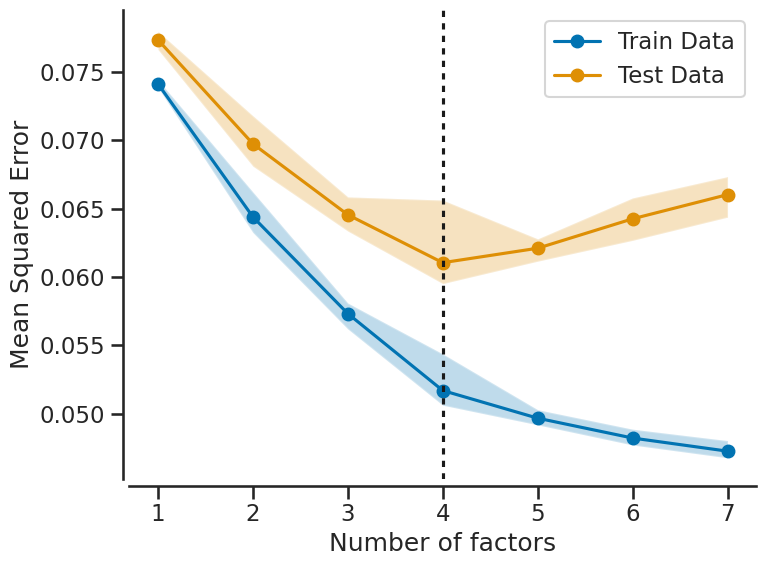

In [10]:
fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

inflection = (groups["MSE"]["mean"]["Test"] > groups["MSE"]["mean"]["Test"].shift()).idxmax() - 1

ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

## Trying on Our Data

In [11]:
# Make sure nnlsm_blockpivot is already defined in your notebook
nnlstsq = nnlsm_blockpivot

def censored_nnlstsq2(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None]  # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:])  # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n_idx in range(B.shape[1]):
        try:
            X[n_idx] = nnlstsq(T[n_idx], rhs[n_idx], is_input_prod=True)[0].T
        except np.linalg.LinAlgError:
            X[n_idx] = np.zeros((A.shape[1],))

    return X.T


def cv_nmf2(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    Args
    ----
    data (ndarray)    : m x n matrix
    rank (int)        : the desired output rank (number of factors)
    M (ndarray)       : m x n binary matrix (zeros indicate heldout values)
    p_holdout (float) : fraction of values to hold out
    tol (float)       : tolerance for convergence
    verbose (bool)    : print debug info
    max_iter (int)    : maximum iterations

    Returns
    -------
    U, Vt, train_err, test_err, converged
    """

    # create the masking matrix if not provided
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout
        min_valid = rank + 1

        # ensure enough True values per row
        for i in range(M.shape[0]):
            if M[i].sum() < min_valid:
                needed = min_valid - M[i].sum()
                zero_indices = np.where(~M[i])[0]
                if len(zero_indices) >= needed:
                    M[i, np.random.choice(zero_indices, size=needed, replace=False)] = True

        # ensure enough True values per column
        for j in range(M.shape[1]):
            if M[:, j].sum() < min_valid:
                needed = min_valid - M[:, j].sum()
                zero_indices = np.where(~M[:, j])[0]
                if len(zero_indices) >= needed:
                    M[np.random.choice(zero_indices, size=needed, replace=False), j] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    mse = 100
    converged = False

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq2(U, data, M)
        U = censored_nnlstsq2(Vt.T, data.T, M.T).T

        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse

        if verbose:
            train_pct = 100 * M.sum() / M.size
            print(f"\tIter {itr+1} = {diff:.5f}")
            print(f"\tTrain/Test = {train_pct:.2f}/{100-train_pct:.2f}")

    # compute train/test errors
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged


In [13]:
#importing data from Modulair MOD-00685
df = pd.read_csv(r'MOD-00685.csv')
df.head()

,timestamp,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:17Z,577610996,2025-12-31T18:59:17Z,MOD-00685,51.2,-0.3,8.543,0.676,0.158,0.029,...,31.660,22.673,14328,14329,14330,14472.0,14497.0,14547.0,14522.0,12.94
1,2025-12-31T23:58:17Z,577610995,2025-12-31T18:58:17Z,MOD-00685,51.7,-0.3,9.063,0.708,0.125,0.023,...,32.586,21.543,14328,14329,14330,14472.0,14497.0,14547.0,14522.0,11.85
2,2025-12-31T23:57:17Z,577610993,2025-12-31T18:57:17Z,MOD-00685,51.6,-0.3,8.758,0.714,0.158,0.022,...,32.354,21.912,14328,14329,14330,14472.0,14497.0,14547.0,14522.0,13.39
3,2025-12-31T23:56:17Z,577610994,2025-12-31T18:56:17Z,MOD-00685,51.2,-0.3,9.603,0.839,0.190,0.033,...,32.133,22.318,14328,14329,14330,14472.0,14497.0,14547.0,14522.0,10.24
4,2025-12-31T23:55:17Z,577608926,2025-12-31T18:55:17Z,MOD-00685,51.1,-0.4,8.368,0.627,0.147,0.044,...,32.130,22.325,14328,14329,14330,14472.0,14497.0,14547.0,14522.0,15.26


In [14]:
#only including columns of interest and non na rows
COLS_TO_INCLUDE = ['timestamp_local','co', 'no2', 'o3', 'no', 'bin0', 'bin1', 'bin2','bin3','bin4','bin5']
df = df[COLS_TO_INCLUDE]
df.dropna()
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-31T18:59:17Z,704.365,31.660,22.673,2.293,8.543,0.676,0.158,0.029,0.024,0.003
1,2025-12-31T18:58:17Z,711.399,32.586,21.543,2.083,9.063,0.708,0.125,0.023,0.030,0.006
2,2025-12-31T18:57:17Z,711.470,32.354,21.912,2.083,8.758,0.714,0.158,0.022,0.024,0.006
3,2025-12-31T18:56:17Z,709.702,32.133,22.318,2.293,9.603,0.839,0.190,0.033,0.023,0.006
4,2025-12-31T18:55:17Z,721.159,32.130,22.325,2.228,8.368,0.627,0.147,0.044,0.015,0.012


In [15]:
#converting to datetime
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-31 18:59:17,704.365,31.660,22.673,2.293,8.543,0.676,0.158,0.029,0.024,0.003
1,2025-12-31 18:58:17,711.399,32.586,21.543,2.083,9.063,0.708,0.125,0.023,0.030,0.006
2,2025-12-31 18:57:17,711.470,32.354,21.912,2.083,8.758,0.714,0.158,0.022,0.024,0.006
3,2025-12-31 18:56:17,709.702,32.133,22.318,2.293,9.603,0.839,0.190,0.033,0.023,0.006
4,2025-12-31 18:55:17,721.159,32.130,22.325,2.228,8.368,0.627,0.147,0.044,0.015,0.012


In [16]:
#taking hourly average of df. round to floor of the hour
df = df.groupby(df['timestamp_local'].dt.floor('h')).agg(co = ('co','mean'),
                                                         no2 = ('no2','mean'),
                                                         o3 = ('o3','mean'),
                                                         no = ('no','mean'),
                                                         bin0 = ('bin0','mean'),
                                                         bin1 = ('bin1','mean'),
                                                         bin2 = ('bin2','mean'),
                                                         bin3 = ('bin3','mean'),
                                                         bin4 = ('bin4','mean'),
                                                         bin5 = ('bin5','mean')).reset_index()

df = df.round(decimals = 2)
df = df.dropna()

In [17]:
df.to_csv('MOD-00685_timeseries_hourly.csv')

In [18]:
df = df.sample(frac=0.2)
df = df.set_index('timestamp_local')

def maximum_absolute_scaling(df):
    # copy the dataframe
    df_scaled = df.copy()
    # apply maximum absolute scaling
    for column in df_scaled.columns:
        df_scaled[column] = df_scaled[column]  / df_scaled[column].abs().max()
    return df_scaled

# call the maximum_absolute_scaling function
df_scaled = maximum_absolute_scaling(df)

df_scaled.head(10)

,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
timestamp_local,,,,,,,,,,
2025-09-13 17:00:00,0.491305,0.693135,0.494180,0.103627,0.106597,0.020397,0.012459,0.012915,0.016227,0.016713
2025-10-02 16:00:00,0.443950,0.622337,0.481364,0.078756,0.031432,0.008215,0.006501,0.007380,0.010142,0.011142
2025-06-02 06:00:00,0.470732,0.612438,0.366255,0.065976,0.046093,0.006799,0.003792,0.003690,0.006085,0.005571
2025-06-25 10:00:00,0.450139,0.233699,0.680541,0.110535,0.123121,0.024363,0.023294,0.025830,0.038540,0.030641
2025-12-02 07:00:00,0.713165,0.755972,0.161317,0.089465,0.123866,0.022946,0.012459,0.011070,0.012170,0.011142
2025-05-31 10:00:00,0.425146,0.196901,0.465256,0.069430,0.071810,0.007082,0.003792,0.003690,0.004057,0.005571
2025-08-05 23:00:00,0.602099,0.144825,0.447619,0.065630,0.590011,0.153824,0.047671,0.025830,0.020284,0.013928
2025-09-28 16:00:00,0.440210,0.467614,0.650206,0.081520,0.101006,0.013314,0.005959,0.003690,0.006085,0.005571
2025-04-24 19:00:00,0.683431,0.850011,0.505232,0.081174,0.221270,0.048442,0.034670,0.035055,0.040568,0.038997


In [29]:
replicates = 10

ranks = np.arange(1, 5)

frame = pd.DataFrame()

# fit the models
for rnk, j in itertools.product(ranks, range(replicates)):
    print ("Rank {}.{}".format(rnk, j))

    tr, te, converged = cv_nmf2(df_scaled.values, rnk, verbose=True, tol=1e-4, max_iter=150, p_holdout=0.2)[2:]

    if not converged:
        print ("there was a convergence issue: {}".format(rnk))

    else:
        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train", "Converged": converged},
            {"Rank": rnk, "MSE": te, "Group": "Test", "Converged": converged}])

        frame = pd.concat([frame, new_rows], ignore_index=True)

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

Streaming output truncated to the last 5000 lines.
	Train/Test = 80.25/19.75
	Iter 7 = -0.05516
	Train/Test = 80.25/19.75
	Iter 8 = -0.05252
	Train/Test = 80.25/19.75
	Iter 9 = -0.04637
	Train/Test = 80.25/19.75
	Iter 10 = -0.04143
	Train/Test = 80.25/19.75
	Iter 11 = -0.04127
	Train/Test = 80.25/19.75
	Iter 12 = -0.04249
	Train/Test = 80.25/19.75
	Iter 13 = -0.04438
	Train/Test = 80.25/19.75
	Iter 14 = -0.04659
	Train/Test = 80.25/19.75
	Iter 15 = -0.04906
	Train/Test = 80.25/19.75
	Iter 16 = -0.05177
	Train/Test = 80.25/19.75
	Iter 17 = -0.05466
	Train/Test = 80.25/19.75
	Iter 18 = -0.05773
	Train/Test = 80.25/19.75
	Iter 19 = -0.06099
	Train/Test = 80.25/19.75
	Iter 20 = -0.06444
	Train/Test = 80.25/19.75
	Iter 21 = -0.06808
	Train/Test = 80.25/19.75
	Iter 22 = -0.07190
	Train/Test = 80.25/19.75
	Iter 23 = -0.07593
	Train/Test = 80.25/19.75
	Iter 24 = -0.08017
	Train/Test = 80.25/19.75
	Iter 25 = -0.08464
	Train/Test = 80.25/19.75
	Iter 26 = -0.08934
	Train/Test = 80.25/19.75
	Iter 

In [31]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.017069  0.002078  0.014872  0.014965  0.016811  0.020274   
      2      9.0  0.102363  0.255531  0.014038  0.014794  0.017016  0.478802   
      3      3.0  0.036957  0.016158  0.022978  0.024005  0.033244  0.052507   
      4      1.0  1.272341       NaN  1.272341  1.272341  1.272341  1.272341   
Train 1     10.0  0.008485  0.000139  0.008300  0.008315  0.008491  0.008673   
      2      9.0  0.004744  0.000214  0.004357  0.004467  0.004711  0.005047   
      3      3.0  0.003876  0.001383  0.003052  0.003057  0.003102  0.005236   
      4      1.0  0.001893       NaN  0.001893  0.001893  0.001893  0.001893   

                      
                 max  
Group Rank            
Test  1     0.022007  
      2     0.783758  
      3     0.054648  
      4     1.272341  
Train 1     0.008678  
      2     0.005121  
      3     0.005473  
      4     0.001893

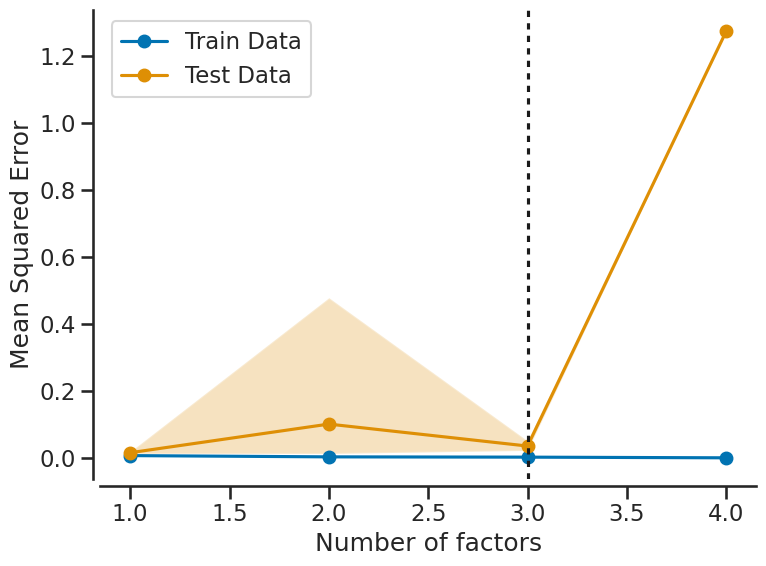

In [32]:
from scipy.signal import argrelextrema

fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

test_mse = groups["MSE"]["mean"]["Test"].values
ranks = groups["MSE"]["mean"]["Test"].index.values

local_min_idx = argrelextrema(test_mse, np.less)[0]

if len(local_min_idx) > 0:
    inflection = ranks[local_min_idx[0]]
    ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

N_FACTORS = 3

#####